# Метод k-ближайших соседей

### Задача 1: Классификация сортов вина (Базовая задача с масштабированием)

- **Датасет:** Встроенный в sklearn (`sklearn.datasets.load_wine`). Там содержатся химические параметры вин из трех разных культиваров (классы 0, 1, 2).
    
- **Что нужно сделать:**
    1. Загрузить датасет, разбейте его на Train и Test (80/20).
    2. Обучить `KNeighborsClassifier` с параметром `n_neighbors=5` на **сырых** (немасштабированных) данных. Посчитать метрику `accuracy_score` на тестовой выборке.
    3. Применить `StandardScaler` к признакам. Снова обучить точно такую же модель на отмасштабированных данных.
    4. Сравнить точность. Написать вывод о том, насколько сильно масштаб признаков повлиял на метрику расстояния в k-NN.

In [134]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

df = sklearn.datasets.load_wine(as_frame=True).frame

df = df.dropna()
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='str')

In [135]:
X = df.drop("target", axis=1)
y = df["target"]

In [136]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Сначала обучаем на неотмасштабированных данных

In [137]:
from sklearn.neighbors import KNeighborsClassifier

knc_model = KNeighborsClassifier(n_neighbors=5)

knc_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [138]:
train_accuracy = knc_model.score(X_train, y_train)
print("Training Accuracy:", train_accuracy)

test_accuracy = knc_model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.7535211267605634
Test Accuracy: 0.7222222222222222


Теперь масштабируем

In [139]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

from sklearn.neighbors import KNeighborsClassifier

knc2_model = KNeighborsClassifier(n_neighbors=5)

knc2_model.fit(X_train_scaled, y_train)

train_accuracy = knc2_model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_accuracy)

test_accuracy = knc2_model.score(X_test_scaled, y_test)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9859154929577465
Test Accuracy: 0.9444444444444444


После масштабирования данных accuracy повысилась на ~22%

### Задача 2: Поиск лучшего $k$ (Подбор гиперпараметров)

- **Датасет:** Популярный датасет классификации сердечных заболеваний: **"Heart Disease Dataset"** с Kaggle. Целевая переменная — `target` (1 — есть болезнь, 0 — нет).
    
- **Что нужно сделать:**
    1. Провести предобработку: масштабировать числовые признаки, закодировать категориальные (если они есть).
    2. Написать цикл на Python, который перебирает значение `k` (параметр `n_neighbors`) от 1 до 40 (только нечетные числа).
    3. Внутри цикла обучить k-NN и записать точность (`accuracy_score`) на тренировочной выборке и на тестовой выборке.
    4. Построить график, где по оси X будет значение $k$, а по оси Y — точность (две линии: для Train и для Test).
    5. По графику определить «золотую середину» — такое число $k$, при котором точность на тесте максимальна, а разрыв между Train и Test минимален (укажите точку, где начинается переобучение и недообучение).

In [140]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("heart.csv")

df = df.dropna()
df = df.drop_duplicates()
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

In [141]:
df_encoded = pd.get_dummies(df, columns=['cp', 'restecg'], drop_first=True)
print(df_encoded.head())

   age  sex  trestbps  chol  fbs  thalach  exang  oldpeak  slope  ca  thal  \
0   52    1       125   212    0      168      0      1.0      2   2     3   
1   53    1       140   203    1      155      1      3.1      0   0     3   
2   70    1       145   174    0      125      1      2.6      0   0     3   
3   61    1       148   203    0      161      0      0.0      2   1     3   
4   62    0       138   294    1      106      0      1.9      1   3     2   

   target   cp_1   cp_2   cp_3  restecg_1  restecg_2  
0       0  False  False  False       True      False  
1       0  False  False  False      False      False  
2       0  False  False  False       True      False  
3       0  False  False  False       True      False  
4       0  False  False  False       True      False  


In [142]:
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [143]:
from sklearn.neighbors import KNeighborsClassifier

train_accuracy_list = []
test_accuracy_list = []
diff = []
neighbors_range = range(1, 201)

best_k = None
best_score = -float('inf')

for i in neighbors_range:
    knc_model = KNeighborsClassifier(n_neighbors=i)
    knc_model.fit(X_train_scaled, y_train)
    
    train_accuracy = knc_model.score(X_train_scaled, y_train)
    test_accuracy = knc_model.score(X_test_scaled, y_test)
    
    train_accuracy_list.append(train_accuracy)
    test_accuracy_list.append(test_accuracy)

    gap = abs(train_accuracy - test_accuracy)
    
    balance_score = test_accuracy - gap
    
    print(f"n_neighbors: {i} | Test Acc: {test_accuracy:.4f} | Train Acc: {train_accuracy:.4f} | Gap: {gap:.4f} | Balance Score: {balance_score:.4f}")

    if balance_score > best_score:
        best_score = balance_score
        best_k = i

print(f"Идеальный выбор: n_neighbors = {best_k}")
print(f"Метрика баланса: {best_score:.4f}")

n_neighbors: 1 | Test Acc: 0.7377 | Train Acc: 1.0000 | Gap: 0.2623 | Balance Score: 0.4754
n_neighbors: 2 | Test Acc: 0.7705 | Train Acc: 0.9004 | Gap: 0.1299 | Balance Score: 0.6406
n_neighbors: 3 | Test Acc: 0.7541 | Train Acc: 0.8963 | Gap: 0.1422 | Balance Score: 0.6119
n_neighbors: 4 | Test Acc: 0.7541 | Train Acc: 0.8714 | Gap: 0.1173 | Balance Score: 0.6368
n_neighbors: 5 | Test Acc: 0.7869 | Train Acc: 0.8838 | Gap: 0.0969 | Balance Score: 0.6900
n_neighbors: 6 | Test Acc: 0.7869 | Train Acc: 0.8672 | Gap: 0.0803 | Balance Score: 0.7066
n_neighbors: 7 | Test Acc: 0.7869 | Train Acc: 0.8714 | Gap: 0.0845 | Balance Score: 0.7024
n_neighbors: 8 | Test Acc: 0.7377 | Train Acc: 0.8631 | Gap: 0.1254 | Balance Score: 0.6123
n_neighbors: 9 | Test Acc: 0.7705 | Train Acc: 0.8672 | Gap: 0.0967 | Balance Score: 0.6738
n_neighbors: 10 | Test Acc: 0.7541 | Train Acc: 0.8548 | Gap: 0.1007 | Balance Score: 0.6534
n_neighbors: 11 | Test Acc: 0.7377 | Train Acc: 0.8589 | Gap: 0.1212 | Balance 

Text(0.5, 1.0, 'KNN Test Accuracy for Different k Values')

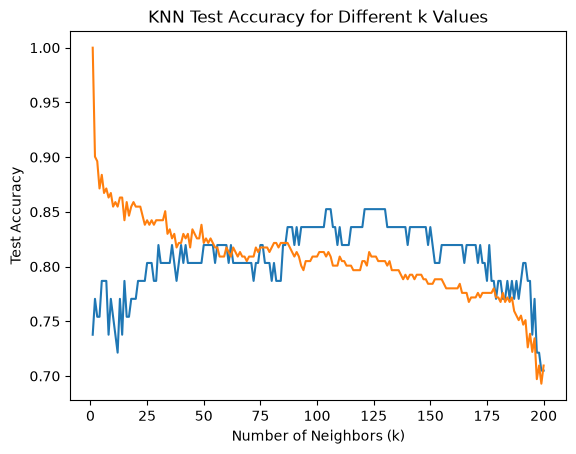

In [144]:
plt.plot(neighbors_range, test_accuracy_list)
plt.plot(neighbors_range, train_accuracy_list)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.title('KNN Test Accuracy for Different k Values')

### Задача 3: k-NN в роли регрессора (Предсказание цен на недвижимость)

Используем k-NN не для определения класса, а для предсказания числа, основываясь на "похожих" объектах.

- **Датасет:** Взять встроенный в sklearn датасет стоимости жилья в Калифорнии (`sklearn.datasets.fetch_california_housing`).
    
- **Что нужно сделать:**
    1. Ограничить датасет первыми 2000 строками (чтобы k-NN не считал слишком долго).
    2. Выделить признаки и таргет (`MedHouseVal` — средняя стоимость дома).
    3. Разбить на Train/Test и обязательно провести масштабирование.
    4. Обучить `KNeighborsRegressor`. Проверить, как смена метрики расстояния (параметр `metric='euclidean'` vs `metric='manhattan'`) влияет на ошибку модели (метрика **MAE**).
    5. **Дополнительно:** Попробовать изменить параметр `weights='uniform'` на `weights='distance'`. Этот параметр делает так, что более близкие соседи имеют больший «вес» при голосовании/усреднении, чем те, что находятся чуть дальше. Посмотреть, улучшило ли это метрику MAE.

In [145]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn

df = sklearn.datasets.fetch_california_housing(as_frame=True).frame

df = df.dropna()
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

<Axes: >

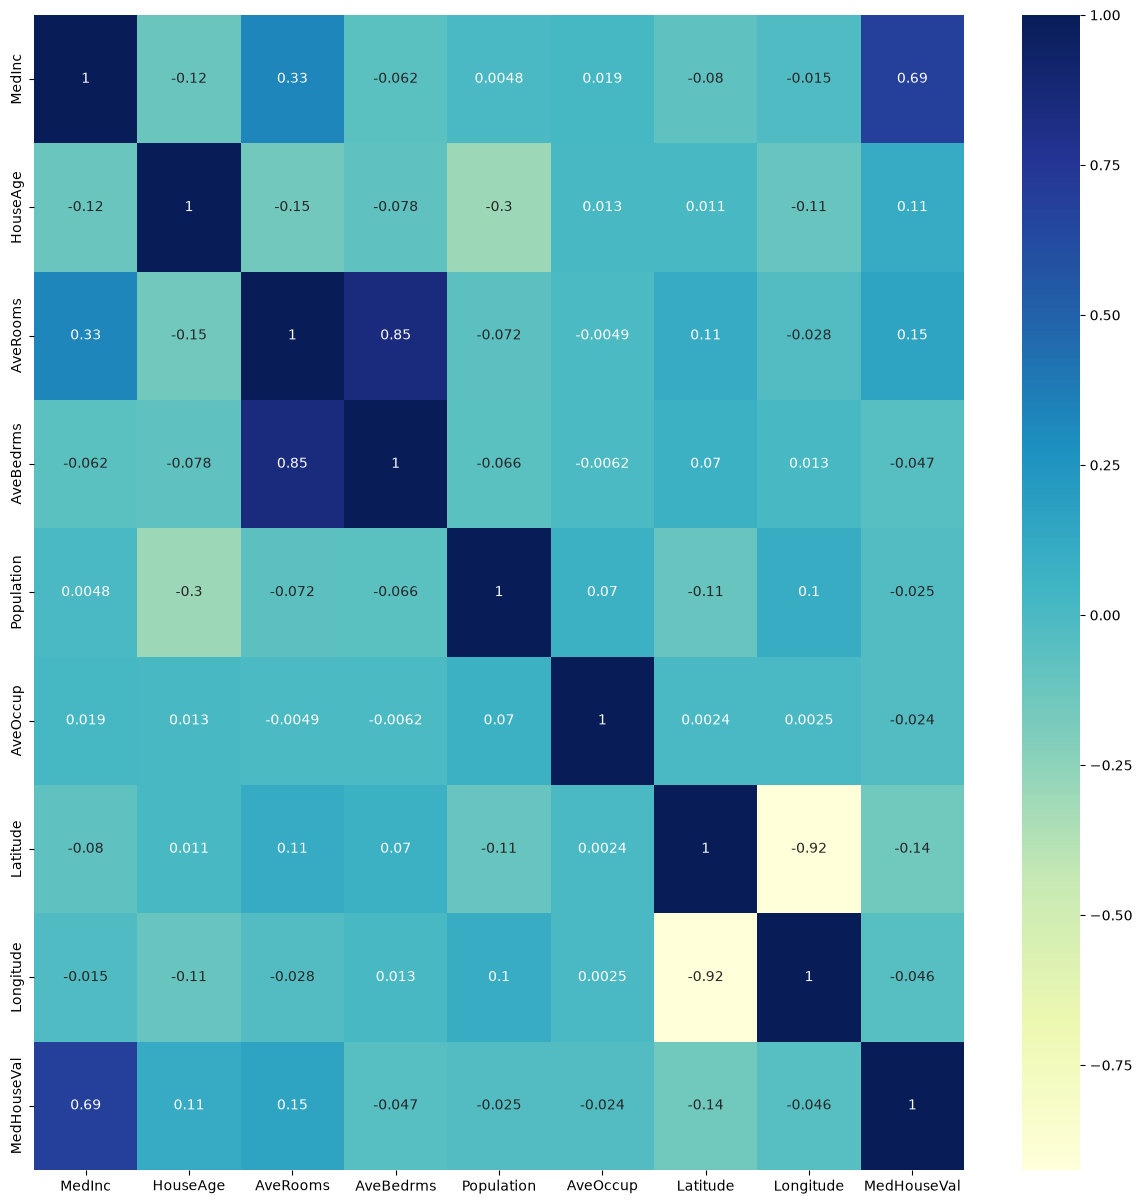

In [146]:
plt.figure(figsize= (15, 15))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="YlGnBu")

In [147]:
X = df.drop("MedHouseVal", axis=1).iloc[:2000]
y = df["MedHouseVal"].iloc[:2000]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (1600, 8)
Размер тестовой выборки: (400, 8)


In [148]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [161]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

train_accuracy_list = []
test_accuracy_list = []
diff = []
neighbors_range = range(1, 26)

best_k = None
best_score = -float('inf')

for i in neighbors_range:
    knc_model = KNeighborsRegressor(n_neighbors=i, metric='manhattan', weights='uniform')
    knc_model.fit(X_train_scaled, y_train)
    
    train_accuracy = knc_model.score(X_train_scaled, y_train)
    test_accuracy = knc_model.score(X_test_scaled, y_test)
    
    train_accuracy_list.append(train_accuracy)
    test_accuracy_list.append(test_accuracy)

    gap = abs(train_accuracy - test_accuracy)
    
    balance_score = max(test_accuracy, train_accuracy) - gap
    
    print(f"n_neighbors: {i} | Test Acc: {test_accuracy:.4f} | Train Acc: {train_accuracy:.4f} | Gap: {gap:.4f} | Balance Score: {balance_score:.4f}")

    if balance_score > best_score:
        best_score = balance_score
        best_k = i

print(f"Идеальный выбор: n_neighbors = {best_k}")
print(f"Метрика баланса: {best_score:.4f}")

n_neighbors: 1 | Test Acc: 0.7144 | Train Acc: 1.0000 | Gap: 0.2856 | Balance Score: 0.7144
n_neighbors: 2 | Test Acc: 0.7876 | Train Acc: 0.9033 | Gap: 0.1157 | Balance Score: 0.7876
n_neighbors: 3 | Test Acc: 0.8107 | Train Acc: 0.8686 | Gap: 0.0578 | Balance Score: 0.8107
n_neighbors: 4 | Test Acc: 0.8161 | Train Acc: 0.8567 | Gap: 0.0406 | Balance Score: 0.8161
n_neighbors: 5 | Test Acc: 0.8213 | Train Acc: 0.8511 | Gap: 0.0298 | Balance Score: 0.8213
n_neighbors: 6 | Test Acc: 0.8182 | Train Acc: 0.8418 | Gap: 0.0236 | Balance Score: 0.8182
n_neighbors: 7 | Test Acc: 0.8233 | Train Acc: 0.8388 | Gap: 0.0156 | Balance Score: 0.8233
n_neighbors: 8 | Test Acc: 0.8257 | Train Acc: 0.8319 | Gap: 0.0061 | Balance Score: 0.8257
n_neighbors: 9 | Test Acc: 0.8238 | Train Acc: 0.8288 | Gap: 0.0049 | Balance Score: 0.8238
n_neighbors: 10 | Test Acc: 0.8222 | Train Acc: 0.8265 | Gap: 0.0044 | Balance Score: 0.8222
n_neighbors: 11 | Test Acc: 0.8223 | Train Acc: 0.8221 | Gap: 0.0003 | Balance 

Если я меняю `weights='uniform'` на `weights='distance'`, то метрика баланса ухудшается на 0.2 и train accuracy зависает на значении 1

Text(0.5, 1.0, 'KNN Test Accuracy for Different k Values')

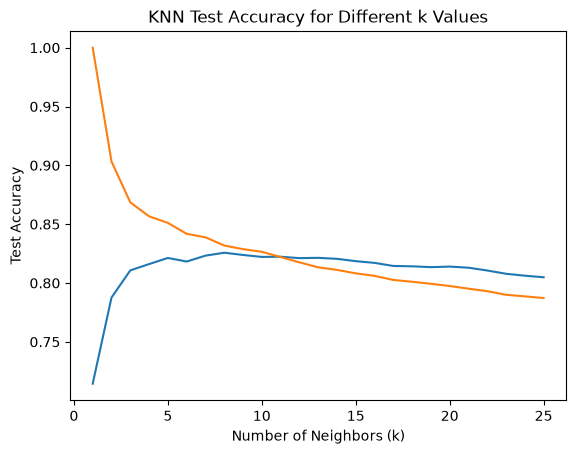

In [162]:
plt.plot(neighbors_range, test_accuracy_list)
plt.plot(neighbors_range, train_accuracy_list)
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.title('KNN Test Accuracy for Different k Values')